# Downloading the data and computing log-returns

In [ ]:
# Requirements:
#   pip install yfinance pandas numpy matplotlib statsmodels scipy
#

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import norm, probplot

# ----------------------------
# 1) Download S&P 500 data
# ----------------------------
ticker = "TSLA"
start_date = "2021-01-01"
end_date = "2025-12-31"

df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    progress=False,
    auto_adjust= False,
)

# ---- FIX: flatten columns if MultiIndex ----
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Keep Close prices
df = df.dropna(subset=["Close"])
price = df["Close"].astype(float)

#  Log-returns

log_ret = np.log(price).diff().dropna()


# Times series plots



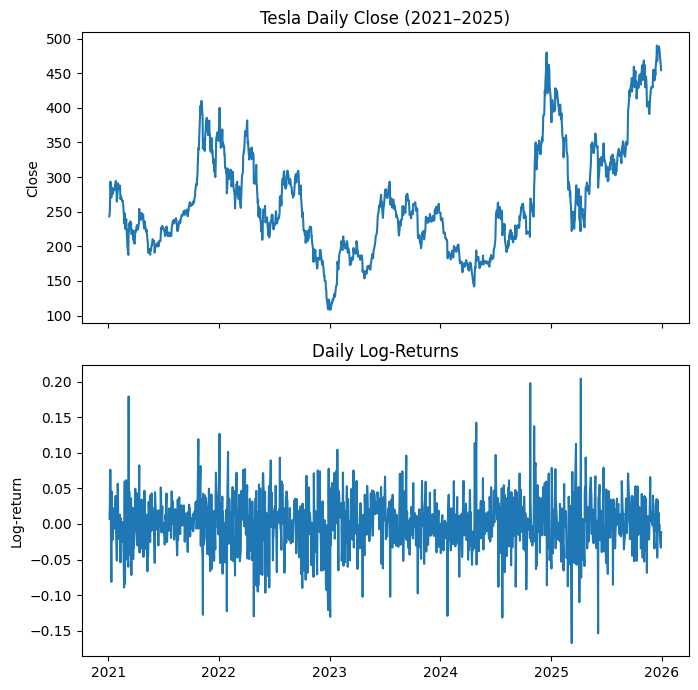

In [ ]:
# ----------------------------
# 2x1 plot: prices and log-returns
# ----------------------------
fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

axes[0].plot(price.index, price)
axes[0].set_title("Tesla Daily Close (2021–2025)")
axes[0].set_ylabel("Close")

axes[1].plot(log_ret.index, log_ret)
axes[1].set_title("Daily Log-Returns")
axes[1].set_ylabel("Log-return")


plt.tight_layout()
plt.savefig('tesla_ret.png', dpi=300)
plt.show()

# Fitting Normal and T-Distributions + Plots

Estimated df = 4.94
Estimated loc = 0.0007
Estimated scale = 0.0297


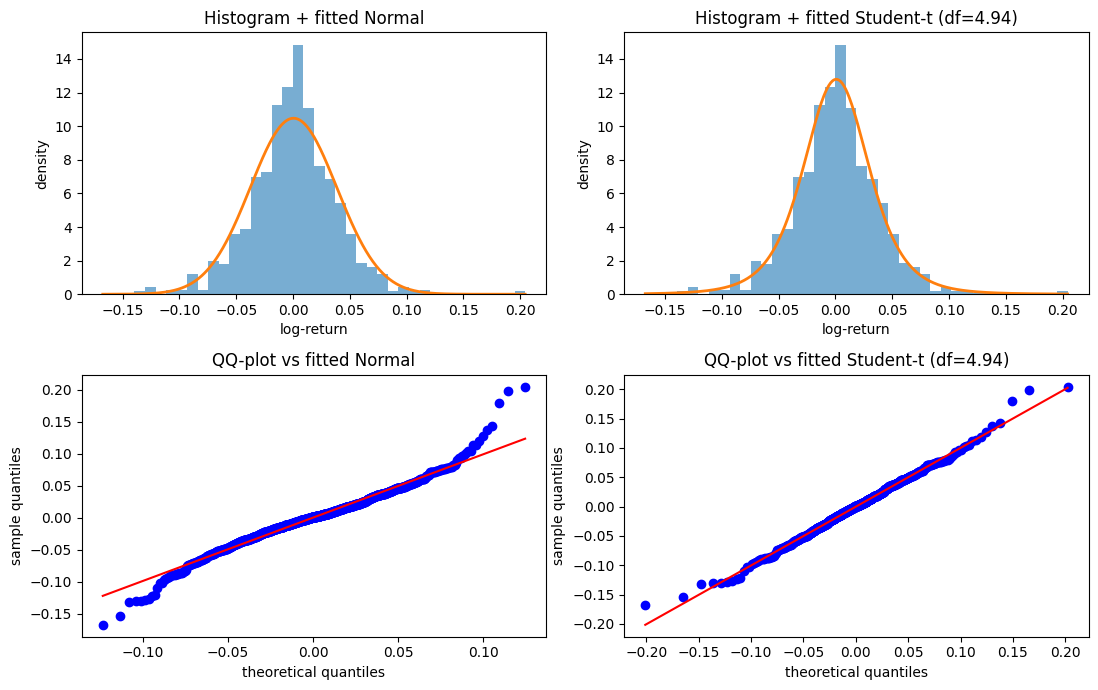

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt


# ---- Fit Normal and Student-t ----
mu_hat, sig_hat = stats.norm.fit(log_ret)
df_hat, loc_hat, scale_hat = stats.t.fit(log_ret)

print(f"Estimated df = {df_hat:.2f}")
print(f"Estimated loc = {loc_hat:.4f}")
print(f"Estimated scale = {scale_hat:.4f}")


# Grid for fitted densities
xx = np.linspace(log_ret.min(), log_ret.max(), 500)

# ---- Create 2x2 figure ----
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

# (1,1) Histogram + fitted Normal density
ax[0, 0].hist(log_ret, bins=40, density=True, alpha=0.6)
ax[0, 0].plot(xx, stats.norm.pdf(xx, loc=mu_hat, scale=sig_hat), linewidth=2)
ax[0, 0].set_title("Histogram + fitted Normal")
ax[0, 0].set_xlabel("log-return")
ax[0, 0].set_ylabel("density")

# (1,2) Histogram + fitted Student-t density
ax[0, 1].hist(log_ret, bins=40, density=True, alpha=0.6)
ax[0, 1].plot(xx, stats.t.pdf(xx, df=df_hat, loc=loc_hat, scale=scale_hat), linewidth=2)
ax[0, 1].set_title(f"Histogram + fitted Student-t (df={df_hat:.2f})")
ax[0, 1].set_xlabel("log-return")
ax[0, 1].set_ylabel("density")

# (2,1) Normal QQ-plot
stats.probplot(log_ret, dist=stats.norm(loc=mu_hat, scale=sig_hat), plot=ax[1, 0])
ax[1, 0].set_title("QQ-plot vs fitted Normal")
ax[1, 0].set_xlabel("theoretical quantiles")
ax[1, 0].set_ylabel("sample quantiles")

# (2,2) Student-t QQ-plot
stats.probplot(log_ret, dist=stats.t(df_hat, loc=loc_hat, scale=scale_hat), plot=ax[1, 1])
ax[1, 1].set_title(f"QQ-plot vs fitted Student-t (df={df_hat:.2f})")
ax[1, 1].set_xlabel("theoretical quantiles")
ax[1, 1].set_ylabel("sample quantiles")

plt.tight_layout()
plt.savefig('tesla.png', dpi=300)
plt.show()


# Kolmogorov-Smirnov Tests

In [ ]:
import numpy as np
import scipy.stats as stats

# KS test against fitted Normal
ks_norm = stats.kstest(
    log_ret,
    'norm',
    args=(mu_hat, sig_hat)
)

# KS test against fitted Student-t
ks_t = stats.kstest(
    log_ret,
    't',
    args=(df_hat, loc_hat, scale_hat)
)

print("KS test vs Normal:")
print(f"  statistic = {ks_norm.statistic:.4f}")
print(f"  p-value   = {ks_norm.pvalue:.4e}\n")

print("KS test vs Student-t:")
print(f"  statistic = {ks_t.statistic:.4f}")
print(f"  p-value   = {ks_t.pvalue:.4e}")


KS test vs Normal:
  statistic = 0.0475
  p-value   = 6.8408e-03

KS test vs Student-t:
  statistic = 0.0180
  p-value   = 8.0556e-01


# Quantile and Probability Computations




In [ ]:

# --- sample quantiles (empirical) ---
q01_emp   = np.quantile(log_ret, 0.01)
q0001_emp = np.quantile(log_ret, 0.001)

print("Empirical (sample) quantiles:")
print(f"  q(0.01)  = {q01_emp:.6f}")
print(f"  q(0.001) = {q0001_emp:.6f}\n")


# --- model-implied tail probabilities at those empirical thresholds ---
p_norm_01   = stats.norm.cdf(q01_emp,   loc=mu_hat, scale=sig_hat)
p_norm_0001 = stats.norm.cdf(q0001_emp, loc=mu_hat, scale=sig_hat)

p_t_01      = stats.t.cdf(q01_emp,   df=df_hat, loc=loc_hat, scale=scale_hat)
p_t_0001    = stats.t.cdf(q0001_emp, df=df_hat, loc=loc_hat, scale=scale_hat)

print("Model-implied tail probabilities P(R <= threshold):")
print(f"  At empirical q(0.01)  = {q01_emp:.6f}:")
print(f"    Normal:   {p_norm_01:.6f}")
print(f"    Student-t:{p_t_01:.6f}\n")

print(f"  At empirical q(0.001) = {q0001_emp:.6f}:")
print(f"    Normal:   {p_norm_0001:.6f}")
print(f"    Student-t:{p_t_0001:.6f}")


Empirical (sample) quantiles:
  q(0.01)  = -0.097152
  q(0.001) = -0.148253

Model-implied tail probabilities P(R <= threshold):
  At empirical q(0.01)  = -0.097152:
    Normal:   0.005177
    Student-t:0.010966

  At empirical q(0.001) = -0.148253:
    Normal:   0.000047
    Student-t:0.002089


# Bootstrap Computations (can be slow)

=== Original data ===
df_hat   = 4.936
q(0.01)  = -0.097152
q(0.001) = -0.148253

=== 95% Percentile CIs (Non-parametric bootstrap) ===
df     CI: 3.841, 6.821
q(0.01)CI: -0.122780, -0.088230
q(0.001)CI:-0.167546, -0.128127

=== 95% Percentile CIs (Parametric bootstrap) ===
df     CI: 3.921, 6.953
q(0.01)CI: -0.114974, -0.085172
q(0.001)CI:-0.237339, -0.122691



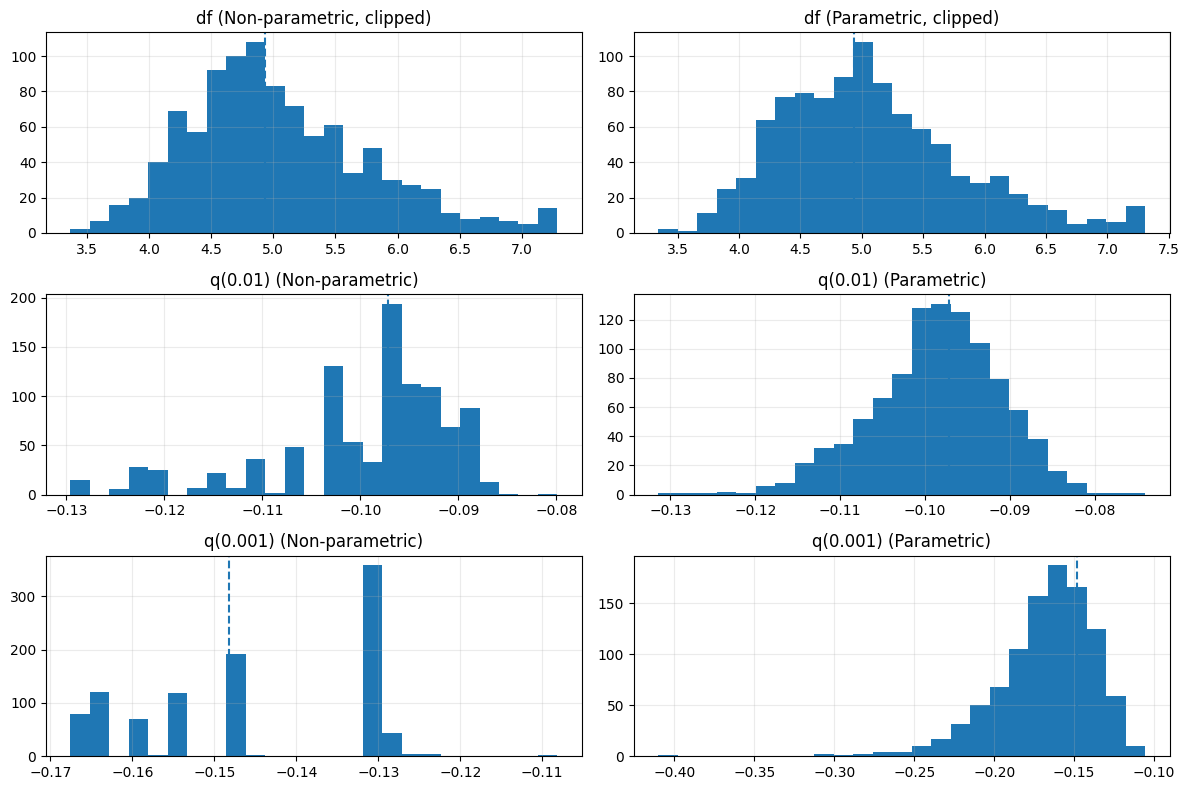

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ---------- helpers ----------
def _clean_1d(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.ndim != 1 or len(x) < 10:
        raise ValueError("log_ret must be a 1D array with at least 10 finite observations.")
    return x

def _percentile_ci(samples, alpha=0.05):
    lo = 100 * (alpha / 2)
    hi = 100 * (1 - alpha / 2)
    return np.percentile(samples, [lo, hi])

def bootstrap_df_and_quantiles(log_ret, B=2000, alpha=0.05, seed=123, make_plots=True):
    """
    Bootstrap (non-parametric + parametric) for:
      - df of fitted Student-t
      - q_0.01 and q_0.001 (sample quantiles)

    Returns:
      df_hat: MLE df on original data
      q_hat: dict with empirical quantiles on original data
      boot_np: dict with arrays for NP bootstrap: df, q01, q001
      boot_par: dict with arrays for Param bootstrap: df, q01, q001
      ci_np: dict with percentile CIs
      ci_par: dict with percentile CIs
    """
    x = _clean_1d(log_ret)
    n = len(x)
    rng = np.random.default_rng(seed)

    # Empirical quantiles on original data
    q01_hat, q001_hat = np.quantile(x, [0.01, 0.001])

    # Fit t on original data (for df + parametric bootstrap DGP)
    df_hat, loc_hat, scale_hat = stats.t.fit(x)

    # Storage
    boot_np = {
        "df": np.empty(B),
        "q01": np.empty(B),
        "q001": np.empty(B),
    }
    boot_par = {
        "df": np.empty(B),
        "q01": np.empty(B),
        "q001": np.empty(B),
    }

    # --- Non-parametric bootstrap: resample x with replacement ---
    for b in range(B):
        xb = rng.choice(x, size=n, replace=True)
        # df estimate from refitting t
        boot_np["df"][b] = stats.t.fit(xb)[0]
        # quantiles from resample
        boot_np["q01"][b], boot_np["q001"][b] = np.quantile(xb, [0.01, 0.001])

    # --- Parametric bootstrap: simulate from fitted t, then refit ---
    for b in range(B):
        xb = stats.t.rvs(df_hat, loc=loc_hat, scale=scale_hat, size=n, random_state=rng)
        boot_par["df"][b] = stats.t.fit(xb)[0]
        boot_par["q01"][b], boot_par["q001"][b] = np.quantile(xb, [0.01, 0.001])

    # CIs (percentile)
    ci_np = {k: _percentile_ci(v, alpha) for k, v in boot_np.items()}
    ci_par = {k: _percentile_ci(v, alpha) for k, v in boot_par.items()}

    # Print summary
    print("=== Original data ===")
    print(f"df_hat   = {df_hat:.3f}")
    print(f"q(0.01)  = {q01_hat:.6f}")
    print(f"q(0.001) = {q001_hat:.6f}\n")

    lvl = int((1 - alpha) * 100)
    print(f"=== {lvl}% Percentile CIs (Non-parametric bootstrap) ===")
    print(f"df     CI: {ci_np['df'][0]:.3f}, {ci_np['df'][1]:.3f}")
    print(f"q(0.01)CI: {ci_np['q01'][0]:.6f}, {ci_np['q01'][1]:.6f}")
    print(f"q(0.001)CI:{ci_np['q001'][0]:.6f}, {ci_np['q001'][1]:.6f}\n")

    print(f"=== {lvl}% Percentile CIs (Parametric bootstrap) ===")
    print(f"df     CI: {ci_par['df'][0]:.3f}, {ci_par['df'][1]:.3f}")
    print(f"q(0.01)CI: {ci_par['q01'][0]:.6f}, {ci_par['q01'][1]:.6f}")
    print(f"q(0.001)CI:{ci_par['q001'][0]:.6f}, {ci_par['q001'][1]:.6f}\n")

    # ----- 3x2 hist grid: rows = (df, q01, q001), cols = (NP, Param) -----
    if make_plots:
        fig, axes = plt.subplots(3, 2, figsize=(12, 8))

        # To avoid ugly df outliers, clip at 99th percentile per method
        df_clip_np = np.percentile(boot_np["df"], 99)
        df_clip_par = np.percentile(boot_par["df"], 99)

        # Row 1: df
        axes[0, 0].hist(np.clip(boot_np["df"], 0, df_clip_np), bins=25)
        axes[0, 0].axvline(df_hat, linestyle="--")
        axes[0, 0].set_title("df (Non-parametric, clipped)")

        axes[0, 1].hist(np.clip(boot_par["df"], 0, df_clip_par), bins=25)
        axes[0, 1].axvline(df_hat, linestyle="--")
        axes[0, 1].set_title("df (Parametric, clipped)")

        # Row 2: q(0.01)
        axes[1, 0].hist(boot_np["q01"], bins=25)
        axes[1, 0].axvline(q01_hat, linestyle="--")
        axes[1, 0].set_title("q(0.01) (Non-parametric)")

        axes[1, 1].hist(boot_par["q01"], bins=25)
        axes[1, 1].axvline(q01_hat, linestyle="--")
        axes[1, 1].set_title("q(0.01) (Parametric)")

        # Row 3: q(0.001)
        axes[2, 0].hist(boot_np["q001"], bins=25)
        axes[2, 0].axvline(q001_hat, linestyle="--")
        axes[2, 0].set_title("q(0.001) (Non-parametric)")

        axes[2, 1].hist(boot_par["q001"], bins=25)
        axes[2, 1].axvline(q001_hat, linestyle="--")
        axes[2, 1].set_title("q(0.001) (Parametric)")

        for ax in axes.ravel():
            ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

    return df_hat, {"q01": q01_hat, "q001": q001_hat}, boot_np, boot_par, ci_np, ci_par


# ---------- run ----------
df_hat, q_hat, boot_np, boot_par, ci_np, ci_par = bootstrap_df_and_quantiles(
    log_ret, B=500, alpha=0.05, seed=123, make_plots=True
)
